# 지도학습 - 회귀 둘러보기
여러 개의 feature를 가지고 연속 된 target 하나를 예측하는 것을 회귀(Regression) 예측이라 한다.

## 최근접 이웃 회귀 모델

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 농어의 길이가 입력(특성)이고 무게가 라벨(타겟)이 된다.
perch_length = np.array([
    8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
    21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
    22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
    27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
    36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
    40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([
    5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
    110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
    130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
    197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
    514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
    820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
    1000.0, 1000.0])
print(perch_length.shape, perch_weight.shape)
     

(56,) (56,)


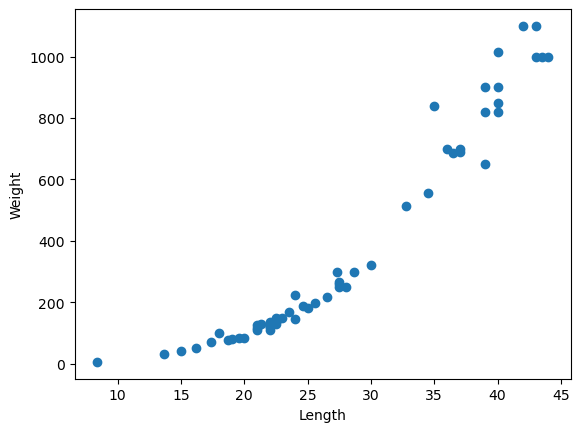

In [4]:
# 두 연속형 데이터를 산포도로 시각화
plt.scatter(perch_length, perch_weight)
plt.xlabel("Length")
plt.ylabel("Weight")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 입력 데이터 2차원으로 변경
perch_length = perch_length.reshape(-1,1)
perch_length.shape

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    perch_length,
    perch_weight,
    random_state=0
)
# stratify : 타겟 데이터의 비율에 맞춰 split 속성은 필요 X
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

In [7]:
# 모델 학습
from sklearn.neighbors import KNeighborsRegressor

# 주어진 데이터와 가장 가까운 이웃 n개를 찾고, 이웃의 평균 값 예측
kn_reg = KNeighborsRegressor()
kn_reg.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [8]:
# 회귀 평가(결정계수 : 1에 가가울수록 좋은 예측)
print(kn_reg.score(X_train, y_train))
print(kn_reg.score(X_test, y_test))

0.9831253192289525
0.9162089041423581


In [ ]:
# 모델 예측
y_pred = kn_reg.predict(X_test[:1])
y_pred

In [ ]:
# 이웃 조회
_, index = kn_reg.kneighbors(X_test[:1])
index

In [ ]:
# 시각화
plt.scatter(X_train, y_train)
plt.scatter(X_train[index[0]], y_train[index[0]], label="neighbor")
plt.scatter(X_test[0], y_test[0], label="y_pred")
plt.scatter(X_test[0], y_pred, label="y_pred")


## 최근접이웃모델의 한계
- 범위를 벗어난 예측이 불가능하다.
- 데이터의 전체적인 경향을 학습하지 못한다.
- 국소적인 정보에만 의존한다.

In [ ]:
kn_reg = KNeighborsRegressor()
kn_reg.fit(X_train, y_train)
y_pred = kn_reg.predict([[50],[70],[300]])
y_pred

In [ ]:
# 이웃 조회
x = 50 # 70 or 100
_, index = kn_reg.kneighbors([[x]])
y_pred = kn_reg.predict([[x]])

In [ ]:
# 시각화
plt.scatter(X_train, y_train)
plt.scatter(X_train[index[0]], y_train[index[0]], label="neighbors")
plt.scatter(x,y_pred,label="y_pred")

plt.xlabel("Length")
plt.ylabel("Weight")
plt.legend()
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression

# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# 예측
y_pred = lin_reg.preict([[50],[70],[100]])
y_pred

AttributeError: 'LinearRegression' object has no attribute 'preict'

NameError: name 'y_pred' is not defined

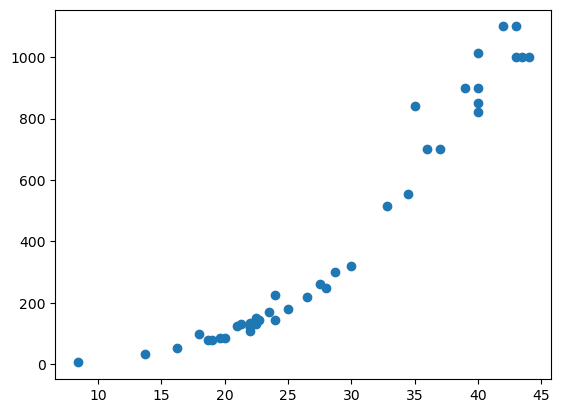

In [14]:
# 시각화
plt.scatter(X_train, y_train)
plt.scatter([[50],[70],[100]], y_pred)

plt.plot([10,100],[lin_reg.predict([[10]]), lin_reg.predict([[100]])])

plt.show()

In [11]:
# 학습 된 회귀계수, 절편
# 회귀 계수는 특성마다 만들어짐 
# y = WX + b (W1 * x + W2*x +....)
print('W:', lin_reg.coef_)
print('b:', lin_reg.intercept_)

pred = lin_reg.coef_* [[50],[70],[100]] +lin_reg.intercept_

pred

W: [37.76648694]
b: -659.8027258214022


array([[1228.52162131],
       [1983.85136016],
       [3116.84596844]])

# 3 개의 feature로 무게 예측

In [15]:
perch_df = pd.read_csv("data/perch_full.csv")
perch_df

,length,height,width,weight
0,8.4,2.11,1.41,5.9
1,13.7,3.53,2.00,32.0
2,15.0,3.82,2.43,40.0
3,16.2,4.59,2.63,51.5
4,17.4,4.59,2.94,70.0
5,18.0,5.22,3.32,100.0
6,18.7,5.20,3.12,78.0
7,19.0,5.64,3.05,80.0
8,19.6,5.14,3.04,85.0
9,20.0,5.08,2.77,85.0


In [ ]:
# 입력/라벨 분리
X = perch_df[['length','height','width']].to_numpy()
y = perch_df['weight'].to_numpy()

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

In [18]:
# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# 모델 평가
print(lin_reg.score(X_train, y_train))
print(lin_reg.score(X_test, y_test))

0.922603499955257
0.8803680435261592


In [21]:
# 회귀계수, 절편 확인
print(lin_reg.coef_, lin_reg.intercept_)

X = X_test[0]
W = lin_reg.coef_
b = lin_reg.intercept_

print((X[0]*W[1]*W[1]+X[2]*W[2]) +b)
print(X @W +b)
print(lin_reg.predict(X_test[:1]))

[37.76648694] -659.8027258214022


IndexError: index 1 is out of bounds for axis 0 with size 1

# 다항 처리

In [20]:
# 다항식 추가 클래스
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)     # 기본 값 degree=2
X = [[2,3]]             # 2개의 특성
X_poly = poly.fit_transform(x)
print(X_Poly)
print(poly.get_feature_names_out())
# bias 값 1, 기존 특성 값 2개, 서로를 곱한 값 1개, 각각 제곱한 값 2개 => 6개

NameError: name 'x' is not defined

In [ ]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X = [[2,3],[3,4]]
X_poly = poly.fit_transform(X)
print(X_poly)
print(poly.get_feature_names_out())

In [ ]:
# 농어 데이터에 2차 다항식 적용
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3개의 특성을 2차 다항식을 적용하여 9개의 특성으로 변경
print(X_train.shape, X_train_poly.shape)
print(X_test.shape, X_test_poly.shape)

pd.DataFrame(X_train_poly, columns=poly.get_feature_names_out()).head()

In [ ]:
# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

# 학습 된 회귀 계수, 절편
print(lin_reg.coef_)
print(lin_reg.intercept_)

In [ ]:
# 모델 평가
print(lin_reg.score(X_train_poly, y_train))
print(lin_reg.score(X_test_poly, y_test))

In [ ]:
# 농어 데이터에 3차 다항식 적용
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3개의 특성을 2차 다항식을 적용하여 9개의 특성으로 변경
print(X_train.shape, X_train_poly.shape)
print(X_test.shape, X_test_poly.shape)

pd.DataFrame(X_train_poly, columns=poly.get_feature_names_out()).head()

In [ ]:
# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

# 학습 된 회귀 계수, 절편
print(lin_reg.coef_)
print(lin_reg.intercept_)

In [ ]:
# 모델 평가
# 훈련 데이터 셋은 잘 맞추지만 평가 데이터 셋에는 맞지 않는 "과대적합" 현상 발생
print(lin_reg.score(X_train_poly, y_train))
print(lin_reg.score(X_test_poly, y_test))